# VM Hardware

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
vm_hardware = pd.read_csv("/Users/biancachiusano/Desktop/uva/thesis/energy-aware-vm-consolidation/datasets/cloud_energy_consumption/vms/2024-12-14T000000Z_2025-04-13T235959Z/vms.csv")
vm_hardware.head()

,vm_id,user_id,project_id,image_ref,vcpus,memory_mb,root_gb,ephemeral_gb
0,6239bcf4,39786247,4ba6ce42,85ecdff4,32.0,60000.0,30.0,160.0
1,80458243,bd41a7e4,74dfdf00,cb92696e,1.0,2000.0,10.0,20.0
2,5d9f6237,7190ddfa,906147a9,78c5906a,4.0,7500.0,30.0,60.0
3,941785dc,1a324c91,f09054da,23658854,2.0,4000.0,10.0,100.0
4,fb856e0f,c1eb1c1c,f09054da,c015d680,4.0,7500.0,30.0,60.0


## Basic EDA Statistics

In [3]:
print("Shape:", vm_hardware.shape)
print("\nMissing values:")
print(vm_hardware.isna().sum())

Shape: (611, 8)

Missing values:
vm_id            0
user_id          0
project_id       0
image_ref        0
vcpus            0
memory_mb        0
root_gb          0
ephemeral_gb    26
dtype: int64


In [4]:
print("\nSummary statistics:")
print(vm_hardware.describe())


Summary statistics:
               vcpus      memory_mb      root_gb  ephemeral_gb
count     611.000000     611.000000   611.000000    585.000000
mean      809.369885   77652.569558    81.235679     63.290598
std      8655.992695  114445.519382   147.451532    118.689986
min         1.000000      10.000000     0.000000      0.000000
25%         4.000000    7000.000000    20.000000      0.000000
50%         8.000000   15000.000000    30.000000      0.000000
75%        64.000000   94000.000000    40.000000     30.000000
max    192000.000000  370000.000000  1000.000000    500.000000


## Outliers

In [6]:
outlier_vcp_values = 128
outlier_memory_values = 1000

high_vcpu = vm_hardware[vm_hardware['vcpus'] > outlier_vcp_values]
low_memory = vm_hardware[vm_hardware['memory_mb'] < outlier_memory_values]

All of the rows where ephemeral_gb is non has high vcpus and really low memory (MB)

In [9]:
print("\nRows with high vcpus:")
print(
    high_vcpu[
        ["vcpus", "memory_mb", "root_gb", "ephemeral_gb"]
    ].head(30)
)


Rows with high vcpus:
        vcpus  memory_mb  root_gb  ephemeral_gb
6      3500.0       30.0     40.0           NaN
7      3500.0       30.0     40.0           NaN
8     15000.0       30.0     60.0           NaN
9      3500.0       30.0     40.0           NaN
10     3500.0       30.0     40.0           NaN
11    60000.0       30.0    160.0           NaN
12    15000.0       30.0     30.0           NaN
13    60000.0       30.0     30.0           NaN
21     7000.0       30.0     40.0           NaN
34     3500.0       20.0      5.0           NaN
36     2000.0       10.0     20.0           NaN
104    2000.0       10.0     20.0           NaN
105    4000.0       10.0    100.0           NaN
106    4000.0       10.0    100.0           NaN
107    4000.0       10.0    100.0           NaN
119    7500.0       30.0     20.0           NaN
142   14000.0       30.0    100.0           NaN
146   30000.0       30.0     30.0           NaN
166    5000.0       10.0      0.0           NaN
169   11000.0    

In [11]:
print("\nRows with low memory:")
print(
    low_memory[
        ["vcpus", "memory_mb", "root_gb", "ephemeral_gb"]
    ].head(30)
)


Rows with low memory:
        vcpus  memory_mb  root_gb  ephemeral_gb
6      3500.0       30.0     40.0           NaN
7      3500.0       30.0     40.0           NaN
8     15000.0       30.0     60.0           NaN
9      3500.0       30.0     40.0           NaN
10     3500.0       30.0     40.0           NaN
11    60000.0       30.0    160.0           NaN
12    15000.0       30.0     30.0           NaN
13    60000.0       30.0     30.0           NaN
21     7000.0       30.0     40.0           NaN
34     3500.0       20.0      5.0           NaN
36     2000.0       10.0     20.0           NaN
104    2000.0       10.0     20.0           NaN
105    4000.0       10.0    100.0           NaN
106    4000.0       10.0    100.0           NaN
107    4000.0       10.0    100.0           NaN
119    7500.0       30.0     20.0           NaN
142   14000.0       30.0    100.0           NaN
146   30000.0       30.0     30.0           NaN
166    5000.0       10.0      0.0           NaN
169   11000.0    

## Missing Ephemeral GB

In [12]:
missing_ephemeral = vm_hardware[vm_hardware["ephemeral_gb"].isna()]

print("\nRows where ephemeral_gb is NaN:")
print(
    missing_ephemeral[
        ["vcpus", "memory_mb", "root_gb", "ephemeral_gb"]
    ].head(26)
)


Rows where ephemeral_gb is NaN:
        vcpus  memory_mb  root_gb  ephemeral_gb
6      3500.0       30.0     40.0           NaN
7      3500.0       30.0     40.0           NaN
8     15000.0       30.0     60.0           NaN
9      3500.0       30.0     40.0           NaN
10     3500.0       30.0     40.0           NaN
11    60000.0       30.0    160.0           NaN
12    15000.0       30.0     30.0           NaN
13    60000.0       30.0     30.0           NaN
21     7000.0       30.0     40.0           NaN
34     3500.0       20.0      5.0           NaN
36     2000.0       10.0     20.0           NaN
104    2000.0       10.0     20.0           NaN
105    4000.0       10.0    100.0           NaN
106    4000.0       10.0    100.0           NaN
107    4000.0       10.0    100.0           NaN
119    7500.0       30.0     20.0           NaN
142   14000.0       30.0    100.0           NaN
146   30000.0       30.0     30.0           NaN
166    5000.0       10.0      0.0           NaN
169   1

## Visualising Outliers

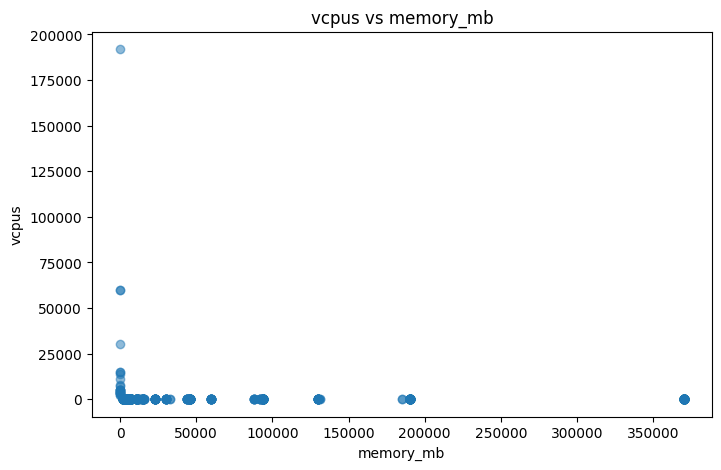

In [13]:
plt.figure(figsize=(8,5))
plt.scatter(vm_hardware["memory_mb"], vm_hardware["vcpus"], alpha=0.5)

plt.xlabel("memory_mb")
plt.ylabel("vcpus")
plt.title("vcpus vs memory_mb")

plt.show()

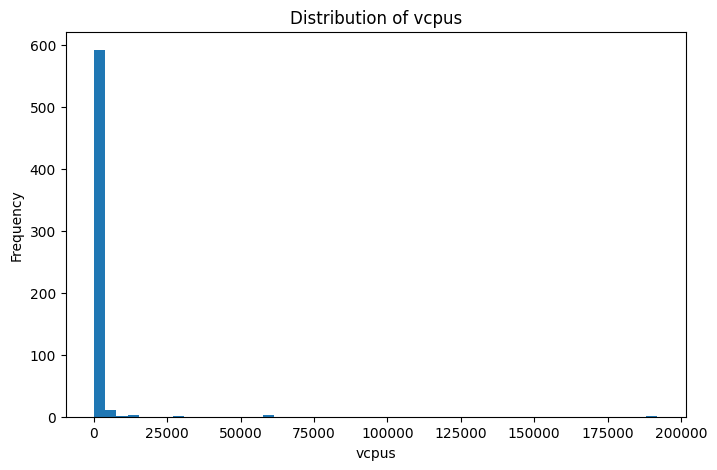

In [14]:
# distribution of vcpus
plt.figure(figsize=(8,5))

plt.hist(vm_hardware["vcpus"], bins=50)

plt.xlabel("vcpus")
plt.ylabel("Frequency")
plt.title("Distribution of vcpus")

plt.show()

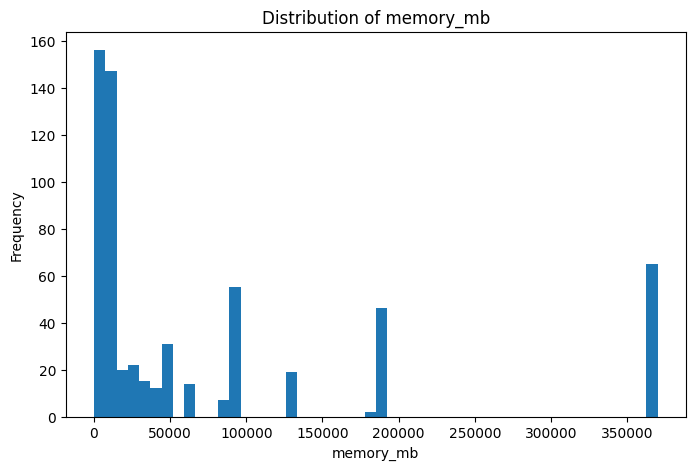

In [15]:
# distribution of memory_mb
plt.figure(figsize=(8,5))

plt.hist(vm_hardware["memory_mb"], bins=50)

plt.xlabel("memory_mb")
plt.ylabel("Frequency")
plt.title("Distribution of memory_mb")

plt.show()

## Swapping Vcpus and memory when ephemeral gb is null

In [16]:
vm_hardware_fixed = vm_hardware.copy()

# Mask where ephemeral_gb is NaN
mask = vm_hardware_fixed["ephemeral_gb"].isna()

# Swap vcpus and memory_mb
vm_hardware_fixed.loc[mask, ["vcpus", "memory_mb"]] = (
    vm_hardware_fixed.loc[mask, ["memory_mb", "vcpus"]].values
)

## Before and After

In [17]:
print("\nAfter swapping:")
print(
    vm_hardware_fixed.loc[
        mask,
        ["vcpus", "memory_mb", "root_gb", "ephemeral_gb"]
    ].head(26)
)

print("\nNew summary statistics:")
print(vm_hardware_fixed[["vcpus", "memory_mb"]].describe())


After swapping:
     vcpus  memory_mb  root_gb  ephemeral_gb
6     30.0     3500.0     40.0           NaN
7     30.0     3500.0     40.0           NaN
8     30.0    15000.0     60.0           NaN
9     30.0     3500.0     40.0           NaN
10    30.0     3500.0     40.0           NaN
11    30.0    60000.0    160.0           NaN
12    30.0    15000.0     30.0           NaN
13    30.0    60000.0     30.0           NaN
21    30.0     7000.0     40.0           NaN
34    20.0     3500.0      5.0           NaN
36    10.0     2000.0     20.0           NaN
104   10.0     2000.0     20.0           NaN
105   10.0     4000.0    100.0           NaN
106   10.0     4000.0    100.0           NaN
107   10.0     4000.0    100.0           NaN
119   30.0     7500.0     20.0           NaN
142   30.0    14000.0    100.0           NaN
146   30.0    30000.0     30.0           NaN
166   10.0     5000.0      0.0           NaN
169   20.0    11000.0      0.0           NaN
171   10.0     5000.0      0.0        

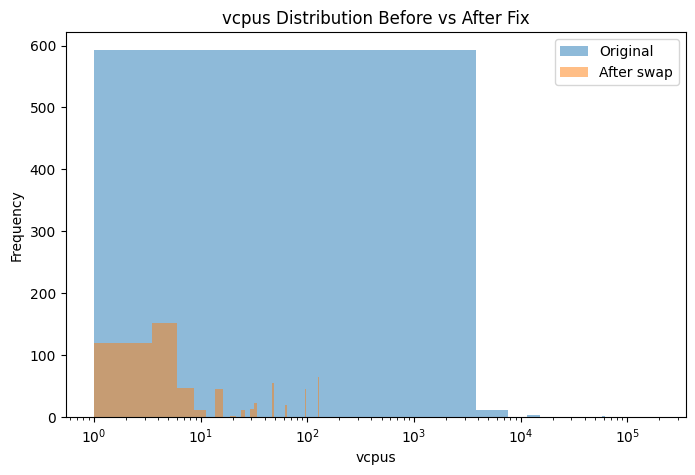

In [18]:
plt.figure(figsize=(8,5))

plt.hist(vm_hardware["vcpus"], bins=50, alpha=0.5, label="Original")
plt.hist(vm_hardware_fixed["vcpus"], bins=50, alpha=0.5, label="After swap")

plt.xscale("log")

plt.xlabel("vcpus")
plt.ylabel("Frequency")
plt.title("vcpus Distribution Before vs After Fix")

plt.legend()

plt.show()

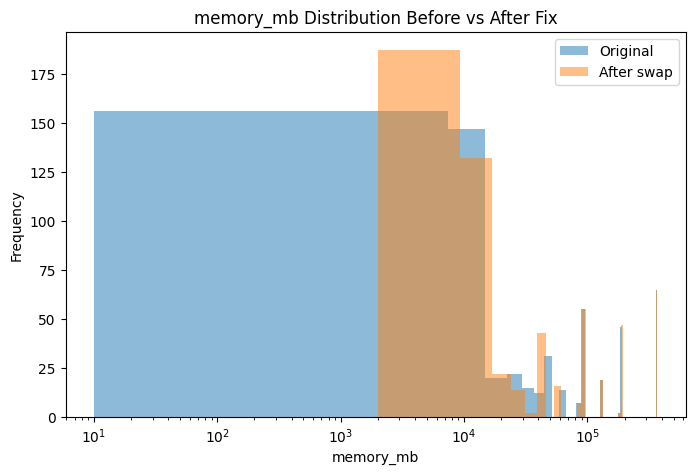

In [19]:
plt.figure(figsize=(8,5))

plt.hist(vm_hardware["memory_mb"], bins=50, alpha=0.5, label="Original")
plt.hist(vm_hardware_fixed["memory_mb"], bins=50, alpha=0.5, label="After swap")

plt.xscale("log")

plt.xlabel("memory_mb")
plt.ylabel("Frequency")
plt.title("memory_mb Distribution Before vs After Fix")

plt.legend()

plt.show()

In [21]:
vm_hardware_fixed.to_csv("/Users/biancachiusano/Desktop/uva/thesis/energy-aware-vm-consolidation/datasets/cloud_energy_consumption/vms/2024-12-14T000000Z_2025-04-13T235959Z/vms_fixed.csv", index=False)